In [1]:
import torch
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

X = housing['data']
y = housing['target']

X_train_full, X_test, y_train_full, y_test = train_test_split(X,y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full)

print(X_train.shape, X_test.shape, X_valid.shape)

scl = StandardScaler()
scl.fit(X_train)

X_train = scl.transform(X_train)
X_test = scl.transform(X_test)
X_valid = scl.transform(X_valid)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
X_valid = torch.FloatTensor(X_valid)

y_train = torch.FloatTensor(y_train).view(-1,1)
y_test = torch.FloatTensor(y_test).view(-1,1)
y_valid = torch.FloatTensor(y_valid).view(-1,1)

# y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
# y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)
# y_valid = torch.tensor(y_valid, dtype=torch.float32).view(-1,1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)

(11610, 8) (5160, 8) (3870, 8)


In [3]:
import torch.nn as nn
import torchmetrics

In [4]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

Epoch: 1/20, Train Loss: 0.92, Train Metric: 0.727, Valid Metric: 0.535, Learning Rate: 0.063, Time: 1.37s
	Checkpoint, valid metric: 0.535
Epoch: 2/20, Train Loss: 0.549, Train Metric: 0.545, Valid Metric: 0.566, Learning Rate: 0.057, Time: 1.83s
Epoch: 3/20, Train Loss: 0.506, Train Metric: 0.52, Valid Metric: 0.486, Learning Rate: 0.051, Time: 1.14s
	Checkpoint, valid metric: 0.486
Epoch: 4/20, Train Loss: 0.489, Train Metric: 0.509, Valid Metric: 0.478, Learning Rate: 0.046, Time: 1.1s
	Checkpoint, valid metric: 0.478
Epoch: 5/20, Train Loss: 0.475, Train Metric: 0.5, Valid Metric: 0.487, Learning Rate: 0.041, Time: 1.24s
Epoch: 6/20, Train Loss: 0.468, Train Metric: 0.496, Valid Metric: 0.469, Learning Rate: 0.037, Time: 1.21s
	Checkpoint, valid metric: 0.469
Epoch: 7/20, Train Loss: 0.461, Train Metric: 0.49, Valid Metric: 0.47, Learning Rate: 0.033, Time: 1.1s
Epoch: 8/20, Train Loss: 0.455, Train Metric: 0.486, Valid Metric: 0.488, Learning Rate: 0.030, Time: 1.44s
Epoch: 9/20,

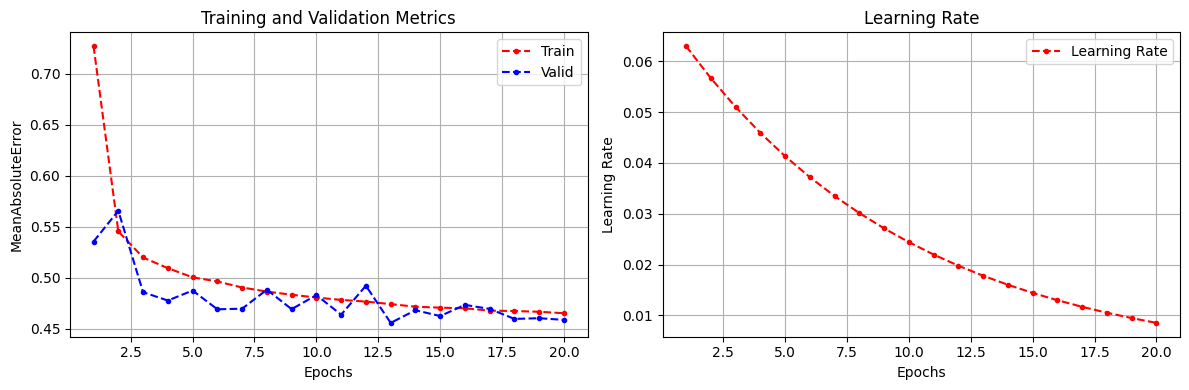

In [5]:
from custom_utils import train, plot_history

# model = nn.Sequential(
# 	nn.Linear(in_features=8, out_features=30), 
# 	nn.Sigmoid(),
# 	nn.Linear(in_features=30, out_features=50), 
# 	nn.Sigmoid(),
# 	nn.Linear(in_features=50, out_features=1)
# ).to(device)

class PriceRegressor(nn.Module):
	def __init__(self, n_features):
		super().__init__()
		self.sequential = nn.Sequential(
			nn.Linear(in_features=n_features, out_features=30), 
			nn.Sigmoid(),
			nn.Linear(in_features=30, out_features=50), 
			nn.Sigmoid(),
			nn.Linear(in_features=50, out_features=1)
		)
        
	def forward(self, X):
		y = self.sequential(X)
		return y
model = PriceRegressor(n_features=8).to(device)

learning_rate = 0.7
n_epochs = 20
patience = n_epochs // 10
warmup_epochs = patience // 2

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate, momentum=0.2)
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1, total_iters=warmup_epochs)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs=n_epochs, 
	# warmup_scheduler=warmup_scheduler, 
	scheduler=scheduler, 
	# patience=patience,
	checkpoint_path='best_model.pt',
	clip_grad_norm=3.0
    )
plot_history(history, metric)

Epoch: 1/20, Train Loss: 0.902, Train Metric: 0.566, Valid Metric: 0.555, Learning Rate: 0.063, Time: 1.55s
	Checkpoint, valid metric: 0.555
Epoch: 2/20, Train Loss: 1.471, Train Metric: 0.545, Valid Metric: 0.513, Learning Rate: 0.057, Time: 1.2s
	Checkpoint, valid metric: 0.513
Epoch: 3/20, Train Loss: 1.264, Train Metric: 0.54, Valid Metric: 0.53, Learning Rate: 0.051, Time: 1.47s
Epoch: 4/20, Train Loss: 1.401, Train Metric: 0.54, Valid Metric: 0.531, Learning Rate: 0.046, Time: 1.16s
Epoch: 5/20, Train Loss: 1.125, Train Metric: 0.538, Valid Metric: 0.517, Learning Rate: 0.041, Time: 1.1s
Epoch: 6/20, Train Loss: 1.505, Train Metric: 0.538, Valid Metric: 0.524, Learning Rate: 0.037, Time: 1.16s
Epoch: 7/20, Train Loss: 1.522, Train Metric: 0.535, Valid Metric: 0.536, Learning Rate: 0.033, Time: 1.32s
Epoch: 8/20, Train Loss: 1.625, Train Metric: 0.534, Valid Metric: 0.524, Learning Rate: 0.030, Time: 1.13s
Epoch: 9/20, Train Loss: 1.679, Train Metric: 0.535, Valid Metric: 0.512, L

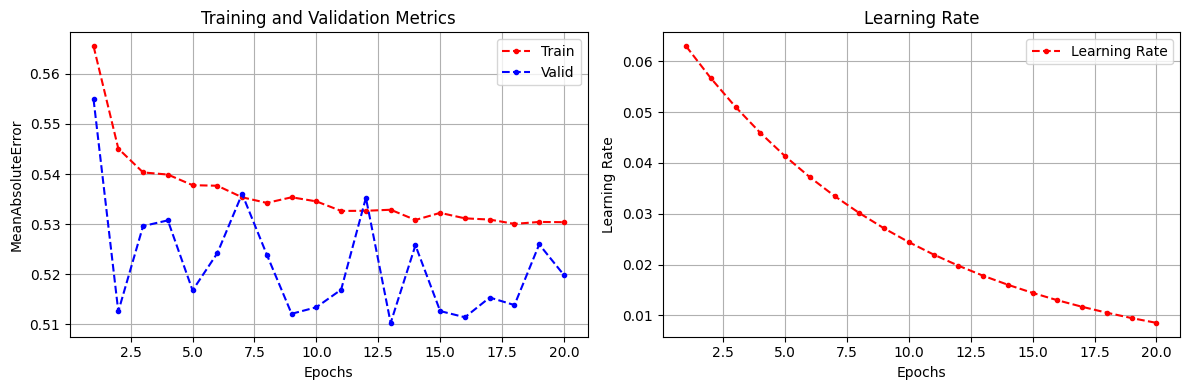

In [6]:
class ResidualRegressor(nn.Module):
	def __init__(self, n_features):
		super().__init__()
		self.sequential = nn.Sequential(
			nn.Linear(in_features=n_features, out_features=30), 
			nn.Sigmoid(),
			nn.Linear(in_features=30, out_features=10), 
			nn.Sigmoid(),
		)
		self.output_layer = nn.Linear(in_features=10 + n_features, out_features=1)
        
	def forward(self, X):
		y_seqential = self.sequential(X)
		y_combined = torch.concat([X, y_seqential], dim=1)
		y = self.output_layer(y_combined)
		return y
model = ResidualRegressor(n_features=8).to(device)

learning_rate = 0.7
n_epochs = 20
patience = n_epochs // 10
warmup_epochs = patience // 2

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate, momentum=0.2)
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1, total_iters=warmup_epochs)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs=n_epochs, 
	# warmup_scheduler=warmup_scheduler, 
	scheduler=scheduler, 
	# patience=patience,
	checkpoint_path='best_model.pt',
	clip_grad_norm=3.0
    )
plot_history(history, metric)

In [7]:
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

Epoch: 1/20, Train Loss: 0.777, Train Metric: 0.655, Valid Metric: 0.528, Learning Rate: 0.063, Time: 1.44s
	Checkpoint, valid metric: 0.528
Epoch: 2/20, Train Loss: 0.526, Train Metric: 0.534, Valid Metric: 0.552, Learning Rate: 0.057, Time: 1.48s
Epoch: 3/20, Train Loss: 0.51, Train Metric: 0.523, Valid Metric: 0.526, Learning Rate: 0.051, Time: 1.24s
	Checkpoint, valid metric: 0.526
Epoch: 4/20, Train Loss: 0.5, Train Metric: 0.518, Valid Metric: 0.511, Learning Rate: 0.046, Time: 1.67s
	Checkpoint, valid metric: 0.511
Epoch: 5/20, Train Loss: 0.491, Train Metric: 0.511, Valid Metric: 0.495, Learning Rate: 0.041, Time: 1.4s
	Checkpoint, valid metric: 0.495
Epoch: 6/20, Train Loss: 0.483, Train Metric: 0.507, Valid Metric: 0.506, Learning Rate: 0.037, Time: 1.64s
Epoch: 7/20, Train Loss: 0.478, Train Metric: 0.504, Valid Metric: 0.498, Learning Rate: 0.033, Time: 1.23s
Epoch: 8/20, Train Loss: 0.474, Train Metric: 0.501, Valid Metric: 0.504, Learning Rate: 0.030, Time: 1.19s
Epoch: 9

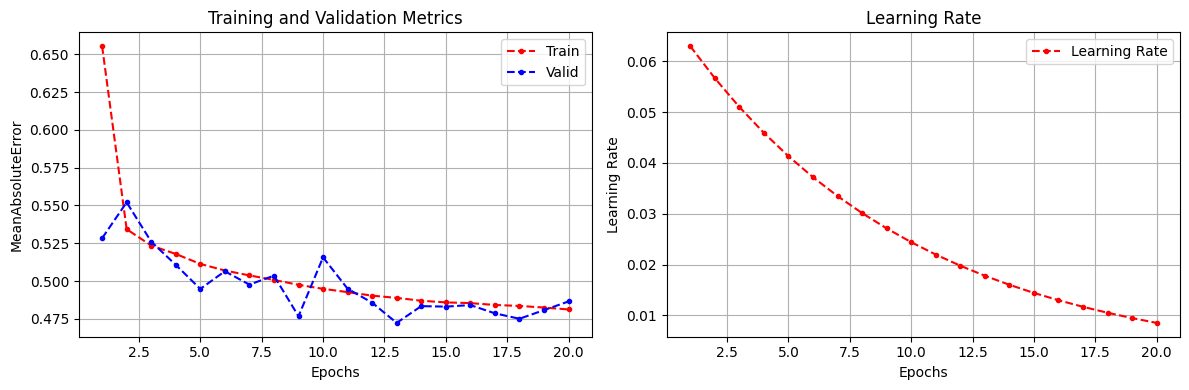

In [8]:
class GeoVsSocialRegressor(nn.Module):
	def __init__(self, n_features):
		super().__init__()
		self.sequential = nn.Sequential(
			nn.Linear(in_features=n_features-2, out_features=30), 
			nn.Sigmoid(),
			nn.Linear(in_features=30, out_features=10), 
			nn.Sigmoid(),
		)
		self.output_layer = nn.Linear(in_features=10 + 2, out_features=1)
        
	def forward(self, X):
		X_geo = X[:, -2:] # 2 cols
		X_soc = X[:, :-2] # 6 cols
		y_soc = self.sequential(X_soc)
		y_combined = torch.concat([X_geo, y_soc], dim=1)
		y = self.output_layer(y_combined)
		return y
model = GeoVsSocialRegressor(n_features=8).to(device)

learning_rate = 0.7
n_epochs = 20
patience = n_epochs // 10
warmup_epochs = patience // 2

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate, momentum=0.2)
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1, total_iters=warmup_epochs)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs=n_epochs, 
	# warmup_scheduler=warmup_scheduler, 
	scheduler=scheduler, 
	# patience=patience,
	checkpoint_path='best_model.pt',
	clip_grad_norm=3.0
    )
plot_history(history, metric)

# multiple inputs - single output

Epoch: 1/20, Train Loss: 0.691, Train Metric: 0.571, Valid Metric: 0.486, Learning Rate: 0.063, Time: 1.36s
	Checkpoint, valid metric: 0.486
Epoch: 2/20, Train Loss: 0.489, Train Metric: 0.5, Valid Metric: 0.484, Learning Rate: 0.057, Time: 1.3s
	Checkpoint, valid metric: 0.484
Epoch: 3/20, Train Loss: 0.435, Train Metric: 0.478, Valid Metric: 0.474, Learning Rate: 0.051, Time: 1.29s
	Checkpoint, valid metric: 0.474
Epoch: 4/20, Train Loss: 0.419, Train Metric: 0.466, Valid Metric: 0.447, Learning Rate: 0.046, Time: 1.21s
	Checkpoint, valid metric: 0.447
Epoch: 5/20, Train Loss: 0.405, Train Metric: 0.457, Valid Metric: 0.46, Learning Rate: 0.041, Time: 1.2s
Epoch: 6/20, Train Loss: 0.395, Train Metric: 0.45, Valid Metric: 0.443, Learning Rate: 0.037, Time: 1.23s
	Checkpoint, valid metric: 0.443
Epoch: 7/20, Train Loss: 0.388, Train Metric: 0.446, Valid Metric: 0.446, Learning Rate: 0.033, Time: 1.53s
Epoch: 8/20, Train Loss: 0.381, Train Metric: 0.44, Valid Metric: 0.453, Learning Rat

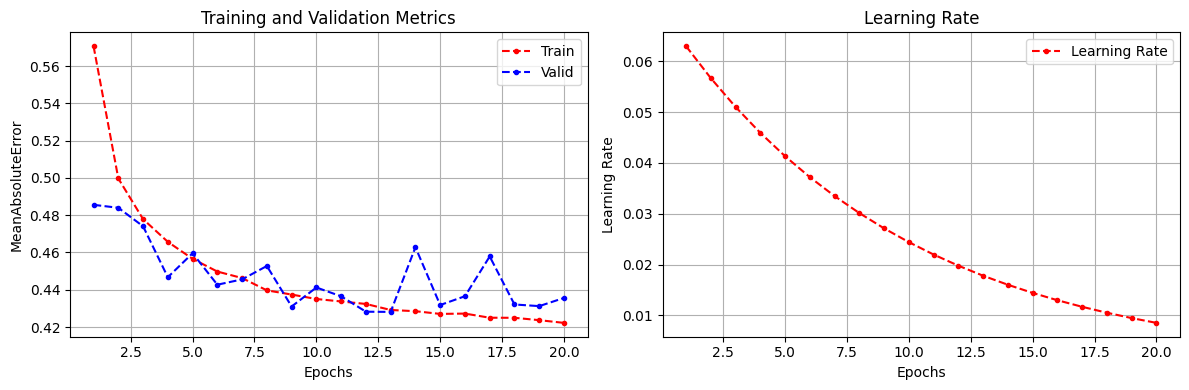

In [9]:
from custom_utils import train, plot_history

train_dataset_geo_soc = TensorDataset(X_train[:, -2:], X_train[:, :-2], y_train) # 2 geo cols, 6 soc cols, labels
valid_dataset_geo_soc = TensorDataset(X_valid[:, -2:], X_valid[:, :-2], y_valid) # 2 geo cols, 6 soc cols, labels
test_dataset_geo_soc = TensorDataset(X_test[:, -2:], X_test[:, :-2], y_test) # 2 geo cols, 6 soc cols, labels

train_loader_geo_soc = DataLoader(train_dataset_geo_soc, batch_size=32, shuffle=True)
valid_loader_geo_soc = DataLoader(valid_dataset_geo_soc, batch_size=32)
test_loader_geo_soc = DataLoader(test_dataset_geo_soc, batch_size=32)

class GeoVsSocialRegressorV2(nn.Module):
	def __init__(self, n_features):
		super().__init__()
		self.sequential = nn.Sequential(
			nn.Linear(in_features=n_features-2, out_features=30), 
			nn.LeakyReLU(),
			nn.Linear(in_features=30, out_features=10), 
			nn.LeakyReLU(),
		)
		self.output_layer = nn.Linear(in_features=10 + 2, out_features=1)
        
	def forward(self, X_geo, X_soc):
		y_soc = self.sequential(X_soc)
		y_combined = torch.concat([X_geo, y_soc], dim=1)
		y = self.output_layer(y_combined)
		return y
model = GeoVsSocialRegressorV2(n_features=8).to(device)

def use_he_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight, nonlinearity='leaky_relu')
        if module.bias is not None:
            nn.init.zeros_(module.bias) 
model.apply(use_he_init)

learning_rate = 0.7
n_epochs = 20
patience = n_epochs // 10
warmup_epochs = patience // 2

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate, momentum=0.2)
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1, total_iters=warmup_epochs)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader_geo_soc, 
	valid_loader_geo_soc, 
	n_epochs=n_epochs, 
	# warmup_scheduler=warmup_scheduler, 
	scheduler=scheduler, 
	# patience=patience,
	checkpoint_path='best_model.pt',
	clip_grad_norm=3.0
    )
plot_history(history, metric)

# single input - multiple output

Epoch: 1/20, Loss: 3.201, Train Metric: 1.361, Valid Metric: 0.819
Epoch: 2/20, Loss: 1.106, Train Metric: 0.725, Valid Metric: 0.653
Epoch: 3/20, Loss: 0.752, Train Metric: 0.629, Valid Metric: 0.605
Epoch: 4/20, Loss: 0.67, Train Metric: 0.598, Valid Metric: 0.581
Epoch: 5/20, Loss: 0.643, Train Metric: 0.583, Valid Metric: 0.571
Epoch: 6/20, Loss: 0.627, Train Metric: 0.574, Valid Metric: 0.563
Epoch: 7/20, Loss: 0.615, Train Metric: 0.568, Valid Metric: 0.554
Epoch: 8/20, Loss: 0.604, Train Metric: 0.56, Valid Metric: 0.552
Epoch: 9/20, Loss: 0.595, Train Metric: 0.557, Valid Metric: 0.542
Epoch: 10/20, Loss: 0.588, Train Metric: 0.551, Valid Metric: 0.541
Epoch: 11/20, Loss: 0.58, Train Metric: 0.548, Valid Metric: 0.534
Epoch: 12/20, Loss: 0.573, Train Metric: 0.544, Valid Metric: 0.532
Epoch: 13/20, Loss: 0.567, Train Metric: 0.541, Valid Metric: 0.528
Epoch: 14/20, Loss: 0.562, Train Metric: 0.538, Valid Metric: 0.525
Epoch: 15/20, Loss: 0.557, Train Metric: 0.535, Valid Metric

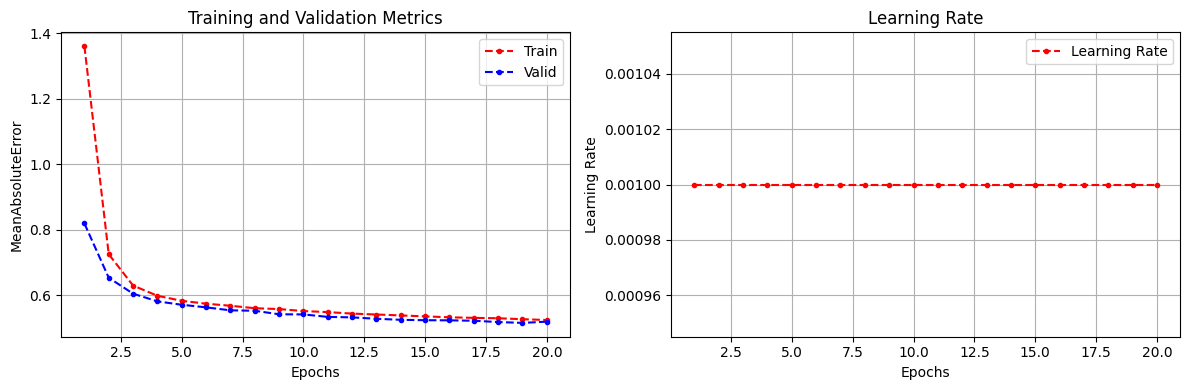

In [12]:
learning_rate = 0.001
n_epochs=20

class GeoVsSocialRegressorMultiOutput(nn.Module):
	def __init__(self, n_features):
		super().__init__()
		self.sequential = nn.Sequential(
			nn.Linear(in_features=n_features-2, out_features=30), 
			nn.LeakyReLU(),
			nn.Linear(in_features=30, out_features=10), 
			nn.LeakyReLU(),
		)
		self.main_output_layer = nn.Linear(in_features=10 + 2, out_features=1)
		self.aux_output_layer = nn.Linear(in_features=10, out_features=1)
        
	def forward(self, X):
		X_geo = X[:, -2:] # 2 cols
		X_soc = X[:, :-2] # 6 cols
		y_seq = self.sequential(X_soc)
		y_combined = torch.concat([X_geo, y_seq], dim=1)
		y_main = self.main_output_layer(y_combined)
		y_aux = self.aux_output_layer(y_seq)
		return y_main, y_aux
model = GeoVsSocialRegressorMultiOutput(n_features=8).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.MeanAbsoluteError().to(device)

def train_multi_output(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
	history = {
		'loss' : [],
		'train_metrics' : [],
		'valid_metrics' : [],
		'learning_rates' : [],
	}
	for epoch in range(n_epochs):
		# Training 
		total_loss = 0
		metric.reset()
		for X_batch, y_batch in train_loader:
			X_batch, y_batch = X_batch.to(device), y_batch.to(device)
			model.train()
			y_pred_main, y_pred_aux = model(X_batch)
			loss_main = criterion(y_pred_main, y_batch)
			loss_aux = criterion(y_pred_aux, y_batch)
			loss = loss_main * 0.8 + loss_aux * 0.2
			total_loss += loss.item()
			loss.backward()
			optimizer.step()
			optimizer.zero_grad()
			metric.update(y_pred_main, y_batch)
		
		avg_loss = total_loss / len(train_loader)
		history['loss'].append(avg_loss)

		avg_metric_train = metric.compute().item()
		history['train_metrics'].append(avg_metric_train)

		# Evaluation 
		model.eval()
		metric.reset()
		with torch.no_grad():
			for X_batch, y_batch in valid_loader:
				X_batch, y_batch = X_batch.to(device), y_batch.to(device)
				y_pred_main, y_pred_aux = model(X_batch)
				metric.update(y_pred_main, y_batch)

		avg_metric_valid = metric.compute().item()
		history['valid_metrics'].append(avg_metric_valid)

		learning_rate = optimizer.param_groups[0]['lr']
		history['learning_rates'].append(learning_rate)

		print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Loss: {round(avg_loss,3)}, '
			+f'Train Metric: {round(avg_metric_train,3)}, ' 
			+f'Valid Metric: {round(avg_metric_valid,3)}'
		)
	return history

history = train_multi_output(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs)
plot_history(history, metric)